In [144]:
# Remember to pip install pandas, matplotlib, scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.spatial import ConvexHull, QhullError

# Enable inline mode for matplotlib so that Jupyter displays graphs
%matplotlib inline 

In [145]:
# In the source dataset, 0 represents an unrecorded measurement.
# Reads the CSV file and sets 0 values to NULL
df = pd.read_csv(
    "Allsharkteeth.csv", 
    skipinitialspace = True,
    na_values = "0"
)
data_frame = df.copy(deep=True)
#data_frame

In [150]:
# Counts how many NULL values in each attribute
count = data_frame.isnull().sum()
count

Locality       0
Specimen #     0
Taxon          0
Position       0
BCW            0
CH             2
DCL            2
IDCL           2
IMCL           2
LCH           68
LCW           66
MCL            2
PCH            2
PCW            2
RH            13
RW            12
TH             0
DS             2
CDS           67
RA            22
dtype: int64

Reusable functions for PCA:

In [146]:
# Get numeric data and standardize features
def get_numeric_data(data_frame):
    num_data = data_frame.drop(
        columns=['Locality', 'Specimen #', 'Taxon', 'Position']
    )

    # Standardizing data
    scaler = StandardScaler()
    scaled_array = scaler.fit_transform(num_data)

    scaled_data = pd.DataFrame(
        scaled_array,
        columns = num_data.columns,
        index = num_data.index
    )
    return scaled_data

In [147]:
# Does the PCA
def plot_pca(data_frame, scaled_data):
    pca = PCA(n_components=2, svd_solver="full")
    pca_scores = pca.fit_transform(scaled_data)

    # Converts PCA back to a usable graph to be plotted
    taxon = data_frame.loc[scaled_data.index, 'Taxon']
    pca_data = pd.DataFrame (
        pca_scores, 
        columns = ["PC1", "PC2"],
        index = scaled_data.index
    )
    pca_data['Taxon'] = taxon

    # Plots the graph
    for name, g in pca_data.groupby("Taxon"):
        sc = plt.scatter(g["PC1"], g["PC2"], s=35, alpha=0.9, label=name)
        color = sc.get_facecolors()[0]
        if len(g) >= 3:
            pts = g[["PC1", "PC2"]].to_numpy()
            try:
                hull = ConvexHull(pts)
                hull_pts = pts[hull.vertices]
                plt.fill(
                    hull_pts[:, 0], hull_pts[:, 1],
                    facecolor=color, alpha=0.18,   # translucent fill
                    edgecolor=color, linewidth=1   # matching outline
                )
            except QhullError:
                pass

    # Variance Ratio
    var = pca.explained_variance_ratio_
    plt.xlabel(f"PC1 ({var[0]*100:.2f}%)")
    plt.ylabel(f"PC2 ({var[1]*100:.2f}%)")

    # Title
    plt.title("PCA by Taxon")
    plt.legend(title="Taxon", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

    return pca, var

In [148]:
def get_loadings(pca, scaled_data, var):
    loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

    plt.figure(figsize=(9, 7))
    plt.axhline(0, linestyle="--", linewidth=1)
    plt.axvline(0, linestyle="--", linewidth=1)

    for i, col in enumerate(scaled_data.columns):
        x, y = loadings[i, 0], loadings[i, 1]
        plt.arrow(0, 0, x, y, head_width=0.02, length_includes_head=True)
        plt.text(x * 1.07, y * 1.07, col, fontsize=9)

    plt.title("PCA Variable Loadings")
    plt.xlabel(f"PC1 ({var[0]*100:.1f}%)")
    plt.ylabel(f"PC2 ({var[1]*100:.1f}%)")
    plt.tight_layout()
    plt.show()

In [149]:
# pca is already fit on scaled_data
def get_weights(pca, scaled_data):
    weights = pd.DataFrame(
        pca.components_.T,
        index=scaled_data.columns,
        columns=["PC1", "PC2"]
    )

    # biggest absolute influence on each PC (signed values kept)
    pc1_ranked = weights["PC1"].abs().sort_values(ascending=False)
    pc2_ranked = weights["PC2"].abs().sort_values(ascending=False)

    print("Top contributors to PC1:")
    print(weights.loc[pc1_ranked.index].head(10), "\n")

    print("Top contributors to PC2:")
    print(weights.loc[pc2_ranked.index].head(10))


PCA with overall median imputation:

In [ ]:
# I'm going to drop the values for:
#   LCH, LCW, CDS
# Because if there are species that don't have that attribute at all, it is not 
# a reliable measurment to use in PCA

cols_to_drop = ['LCH', 'LCW', 'CDS']
data_frame = data_frame.drop(columns=cols_to_drop)

# I'm going to impute the overall median value for all other attributes.

cols_to_impute = [ 
    'RH', 'RW', 'RA', 'CH', 'DCL', 'IDCL', 'IMCL', 'MCL', 'PCH', 'PCW', 'DS'
]

overall_medians = data_frame[cols_to_impute].median()
data_frame[cols_to_impute] = data_frame[cols_to_impute].fillna(overall_medians)


# Sanity check
assert data_frame[cols_to_impute].isna().sum().sum() == 0

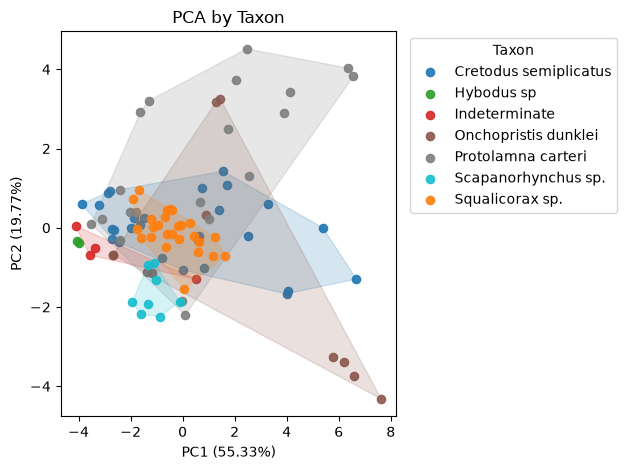

In [152]:
scaled_data = get_numeric_data(data_frame)
pca, var = plot_pca(data_frame, scaled_data)

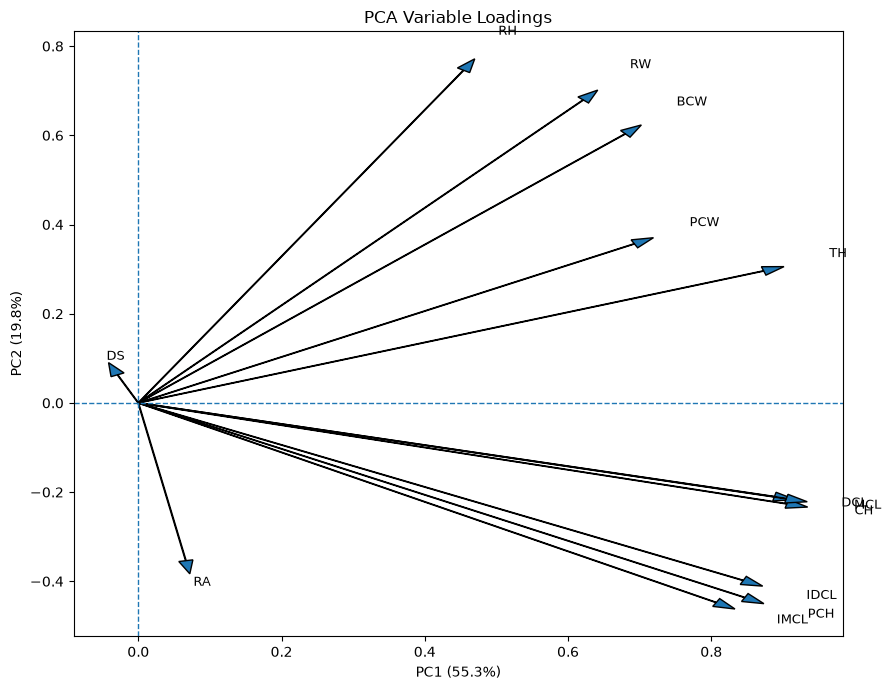

In [153]:
get_loadings(pca, scaled_data, var)

In [154]:
get_weights(pca, scaled_data)

Top contributors to PC1:
           PC1       PC2
CH    0.346701 -0.144951
MCL   0.346468 -0.137533
DCL   0.340302 -0.134662
TH    0.334440  0.189623
PCH   0.324021 -0.279326
IDCL  0.323395 -0.254940
IMCL  0.309041 -0.286749
PCW   0.266831  0.229863
BCW   0.260555  0.386735
RW    0.237956  0.435259 

Top contributors to PC2:
           PC1       PC2
RH    0.174247  0.478739
RW    0.237956  0.435259
BCW   0.260555  0.386735
IMCL  0.309041 -0.286749
PCH   0.324021 -0.279326
IDCL  0.323395 -0.254940
RA    0.026678 -0.237822
PCW   0.266831  0.229863
TH    0.334440  0.189623
CH    0.346701 -0.144951


The first two prinipal components account for 75.1% of varience (PC1 = 55.3%, PC2 = 19.8%). Because morphalogical measurments are the top contributors to PC1, PC1 may represent overall tooth size; PC2 likely seperates specimen by comparing root dimensions to crown dimensions. Heavy overlap on the graph might mean that although some species have noticably different tooth shapes, many are similar enough that measurments alone can't always tell you the taxon. 

PCA with taxon median imputation:

In [ ]:
# Because measurments alone aren't a reliable way to identify species, 
# paleontologiest asigned taxon will be used to impute missing values with
# taxon median. This PCA will be used to help visualize similarities and
# differences between taxon.

taxon_data = df.copy(deep=True)
taxon_data = taxon_data.drop(columns=cols_to_drop)

taxon_medians = taxon_data.groupby('Taxon')[cols_to_impute].transform('median')
taxon_data[cols_to_impute] = taxon_data[cols_to_impute].fillna(taxon_medians)

# For taxon missing all measurments impute with overall median.
taxon_data[cols_to_impute] = taxon_data[cols_to_impute].fillna(overall_medians)

# Sanity check
assert taxon_data[cols_to_impute].isna().sum().sum() == 0

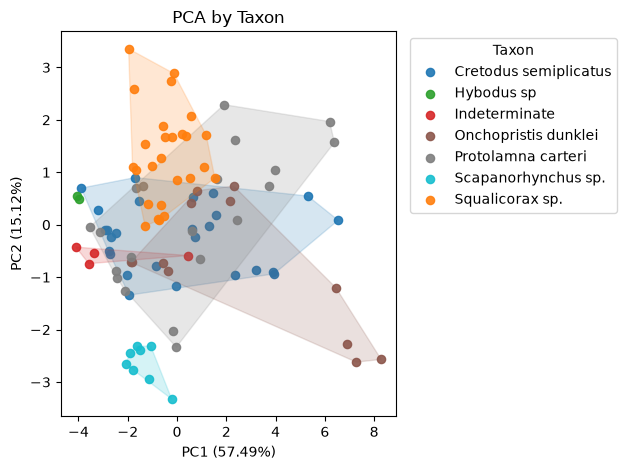

In [156]:
scaled_data = get_numeric_data(taxon_data)
pca, var = plot_pca(taxon_data, scaled_data)

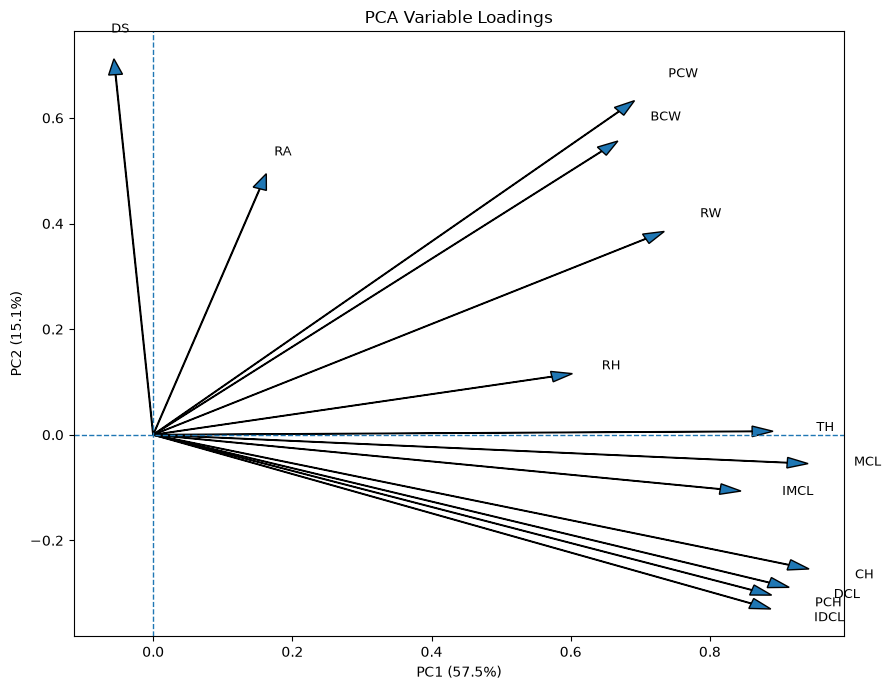

In [157]:
get_loadings(pca, scaled_data, var)

In [158]:
get_weights(pca, scaled_data)

Top contributors to PC1:
           PC1       PC2
CH    0.343010 -0.180336
MCL   0.342504 -0.038758
DCL   0.332622 -0.205023
TH    0.324160  0.004721
PCH   0.323442 -0.215484
IDCL  0.323020 -0.234108
IMCL  0.307404 -0.075630
RW    0.267301  0.273224
PCW   0.251725  0.448946
BCW   0.243025  0.394704 

Top contributors to PC2:
           PC1       PC2
DS   -0.020520  0.505139
PCW   0.251725  0.448946
BCW   0.243025  0.394704
RA    0.059164  0.350788
RW    0.267301  0.273224
IDCL  0.323020 -0.234108
PCH   0.323442 -0.215484
DCL   0.332622 -0.205023
CH    0.343010 -0.180336
RH    0.219240  0.082142


The first two prinipal components account for 72.6% of varience (PC1 = 57.2%, PC2 = 15.1%). Because morphalogical measurments are still the top contributors to PC1, PC1 continues to represent overall tooth size; PC2 changed from the first PCA, now more broadly characterizing by comparing width/angle/DS characteristics to crown dimensions. While Scapanorhynchus and Squalicorax occupy noticably different regions along PC2, heavy overlap between Cretodus and Protolamna may suggest similar feeding strategies. Because taxon identity was used during median imputation, results should be interpreted as a visualization of morphology within known classifications rather than evidence that PCA can independently classify specimens.